In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [3]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

In [4]:
train = pd.read_csv(r"C:\Users\kris2\Downloads\resume_project\Mini Hackathon\train.csv")
public_test = pd.read_csv(r"C:\Users\kris2\Downloads\resume_project\Mini Hackathon\public_test.csv")
private_test = pd.read_csv(r"C:\Users\kris2\Downloads\resume_project\Mini Hackathon\private_test.csv")

In [8]:
train.shape

(10000, 14)

In [9]:
public_test.shape

(3000, 14)

In [10]:
private_test.shape

(3000, 13)

In [11]:
train.head()

,User_ID,Age,Income,City_Tier,Device_Type,Traffic_Source,Pages_Viewed,Products_Viewed,Time_On_Site,Previous_Purchases,Discount_Seen,Browser_Version,Campaign_Code,Converted
0,1,58.0,103593.708812,2,Mobile,Organic,5,4,9.61,3,0,11,2418,0
1,2,26.0,36451.716984,2,Mobile,Social Media,11,3,17.63,2,0,14,1213,0
2,3,19.0,30511.228700,3,Mobile,Referral,1,1,13.25,5,0,5,2849,0
3,4,48.0,87789.172342,3,Mobile,Email,14,12,NaN,1,1,19,7610,0
4,5,35.0,105229.249067,2,Mobile,Social Media,14,21,16.92,1,0,5,9261,0


In [12]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   User_ID             10000 non-null  int64  
 1   Age                 8520 non-null   float64
 2   Income              9016 non-null   float64
 3   City_Tier           10000 non-null  int64  
 4   Device_Type         10000 non-null  object 
 5   Traffic_Source      10000 non-null  object 
 6   Pages_Viewed        10000 non-null  int64  
 7   Products_Viewed     10000 non-null  int64  
 8   Time_On_Site        8152 non-null   float64
 9   Previous_Purchases  10000 non-null  int64  
 10  Discount_Seen       10000 non-null  int64  
 11  Browser_Version     10000 non-null  int64  
 12  Campaign_Code       10000 non-null  int64  
 13  Converted           10000 non-null  int64  
dtypes: float64(3), int64(9), object(2)
memory usage: 1.1+ MB


In [13]:
train.describe()

,User_ID,Age,Income,City_Tier,Pages_Viewed,Products_Viewed,Time_On_Site,Previous_Purchases,Discount_Seen,Browser_Version,Campaign_Code,Converted
count,10000.00000,8520.000000,9016.000000,10000.000000,10000.00000,10000.000000,8152.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,41.457746,69961.772797,1.933400,15.60850,15.219300,13.667241,2.972500,0.540700,12.473900,5511.162200,0.30870
std,2886.89568,13.770164,24790.673822,0.737712,8.62346,8.927563,19.438244,1.738691,0.498366,6.892856,2596.933802,0.46198
min,1.00000,18.000000,12000.000000,1.000000,1.00000,1.000000,0.800000,0.000000,0.000000,1.000000,1000.000000,0.00000
25%,2500.75000,29.000000,52294.644359,1.000000,8.00000,8.000000,7.640000,2.000000,0.000000,7.000000,3251.750000,0.00000
50%,5000.50000,41.000000,70171.613672,2.000000,16.00000,15.000000,11.145000,3.000000,1.000000,12.000000,5515.500000,0.00000
75%,7500.25000,53.000000,86907.747154,2.000000,23.00000,23.000000,15.630000,4.000000,1.000000,18.000000,7759.000000,1.00000
max,10000.00000,65.000000,161687.774167,3.000000,30.00000,37.000000,607.390000,12.000000,1.000000,24.000000,9998.000000,1.00000


In [15]:
train.isnull().sum()

User_ID                  0
Age                   1480
Income                 984
City_Tier                0
Device_Type              0
Traffic_Source           0
Pages_Viewed             0
Products_Viewed          0
Time_On_Site          1848
Previous_Purchases       0
Discount_Seen            0
Browser_Version          0
Campaign_Code            0
Converted                0
dtype: int64

In [16]:
train["Age"]=train["Age"].fillna(train["Age"].mean())

In [20]:
train["Income"]=train["Income"].fillna(train["Income"].mean())

In [18]:
train["Time_On_Site"]=train["Time_On_Site"].fillna(train["Time_On_Site"].mean())

In [19]:
train.isnull().sum()

User_ID               0
Age                   0
Income                0
City_Tier             0
Device_Type           0
Traffic_Source        0
Pages_Viewed          0
Products_Viewed       0
Time_On_Site          0
Previous_Purchases    0
Discount_Seen         0
Browser_Version       0
Campaign_Code         0
Converted             0
dtype: int64

In [22]:
target="Converted"

In [23]:
train[target].value_counts()

Converted
0    6913
1    3087
Name: count, dtype: int64

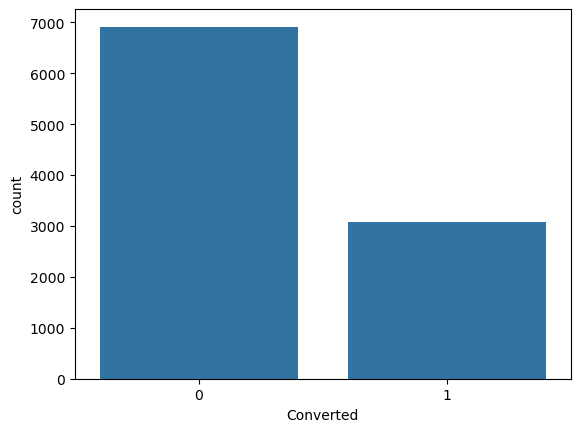

In [24]:
sns.countplot(
    x=train[target]
)
plt.show()

In [25]:
train.drop(
    "User_ID",
    axis=1,
    inplace=True
)

In [26]:
train["Engagement_Score"] = (
    train["Pages_Viewed"] *
    train["Time_On_Site"]
)

In [27]:
train["Product_Interest"] = (
    train["Products_Viewed"] /
    (train["Pages_Viewed"]+1)
)

In [28]:
train["Customer_Value"] = (
    train["Previous_Purchases"] *
    train["Income"]
)

In [29]:
X = train.drop(target, axis=1)
y = train[target]

In [30]:
X.dtypes

Age                   float64
Income                float64
City_Tier               int64
Device_Type            object
Traffic_Source         object
Pages_Viewed            int64
Products_Viewed         int64
Time_On_Site          float64
Previous_Purchases      int64
Discount_Seen           int64
Browser_Version         int64
Campaign_Code           int64
Engagement_Score      float64
Product_Interest      float64
Customer_Value        float64
dtype: object

In [31]:
X_train,X_val,y_train,y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [32]:
X_train = pd.get_dummies(
    X_train,
    drop_first=True
)

X_val = pd.get_dummies(
    X_val,
    drop_first=True
)

In [33]:
X_val = X_val.reindex(
    columns=X_train.columns,
    fill_value=0
)

In [34]:
from sklearn.linear_model import LogisticRegression


lr = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)


lr.fit(
    X_train,
    y_train
)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [35]:
pred = lr.predict(X_val)

In [36]:
print(
    "F1:",
    f1_score(
        y_val,
        pred
    )
)

F1: 0.5494505494505495


In [37]:
from sklearn.ensemble import RandomForestClassifier


rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)


rf.fit(
    X_train,
    y_train
)


rf_pred = rf.predict(X_val)

In [38]:
print(
    f1_score(
        y_val,
        rf_pred
    )
)

0.34065934065934067


In [39]:
probs = rf.predict_proba(X_val)[:,1]


best_score = 0
best_threshold = 0


for t in np.arange(0.1,0.9,0.05):

    prediction = probs > t

    score = f1_score(
        y_val,
        prediction
    )

    if score > best_score:
        best_score = score
        best_threshold = t


print(best_threshold)
print(best_score)

0.25000000000000006
0.5664610207515424


In [41]:
X = train.drop(
    "Converted",
    axis=1
)

y = train["Converted"]

In [42]:
X_encoded = pd.get_dummies(
    X,
    drop_first=True
)

In [43]:
X_encoded.head()

,Age,Income,City_Tier,Pages_Viewed,Products_Viewed,Time_On_Site,Previous_Purchases,Discount_Seen,Browser_Version,Campaign_Code,Engagement_Score,Product_Interest,Customer_Value,Device_Type_Mobile,Device_Type_Tablet,Traffic_Source_Organic,Traffic_Source_Paid Ads,Traffic_Source_Referral,Traffic_Source_Social Media
0,58.0,103593.708812,2,5,4,9.610000,3,0,11,2418,48.050000,0.666667,310781.126435,True,False,True,False,False,False
1,26.0,36451.716984,2,11,3,17.630000,2,0,14,1213,193.930000,0.250000,72903.433968,True,False,False,False,False,True
2,19.0,30511.228700,3,1,1,13.250000,5,0,5,2849,13.250000,0.500000,152556.143500,True,False,False,False,True,False
3,48.0,87789.172342,3,14,12,13.667241,1,1,19,7610,191.341376,0.800000,87789.172342,True,False,False,False,False,False
4,35.0,105229.249067,2,14,21,16.920000,1,0,5,9261,236.880000,1.400000,105229.249067,True,False,False,False,False,True


In [44]:
final_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)


final_model.fit(
    X_encoded,
    y
)

RandomForestClassifier(class_weight='balanced', n_estimators=300,
                       random_state=42)

In [45]:
private_test = private_test.drop(
    "User_ID",
    axis=1
)

In [46]:
private_test["Engagement_Score"] = (
    private_test["Pages_Viewed"] *
    private_test["Time_On_Site"]
)


private_test["Product_Interest"] = (
    private_test["Products_Viewed"] /
    (private_test["Pages_Viewed"]+1)
)


private_test["Customer_Value"] = (
    private_test["Previous_Purchases"] *
    private_test["Income"]
)

In [47]:
private_encoded = pd.get_dummies(
    private_test,
    drop_first=True
)

In [48]:
private_encoded = private_encoded.reindex(
    columns=X_encoded.columns,
    fill_value=0
)

In [49]:
test_prob = final_model.predict_proba(
    private_encoded
)[:,1]


test_pred = (
    test_prob > best_threshold
).astype(int)

In [51]:
private = private_test.copy()

In [53]:
private["Engagement_Score"] = (
    private["Pages_Viewed"] *
    private["Time_On_Site"]
)


private["Product_Interest"] = (
    private["Products_Viewed"] /
    (private["Pages_Viewed"] + 1)
)


private["Customer_Value"] = (
    private["Previous_Purchases"] *
    private["Income"]
)

In [54]:
private_encoded = pd.get_dummies(
    private,
    drop_first=True
)

In [55]:
private_encoded.head()

,Age,Income,City_Tier,Pages_Viewed,Products_Viewed,Time_On_Site,Previous_Purchases,Discount_Seen,Browser_Version,Campaign_Code,Engagement_Score,Product_Interest,Customer_Value,Device_Type_Mobile,Device_Type_Tablet,Traffic_Source_Organic,Traffic_Source_Paid Ads,Traffic_Source_Referral,Traffic_Source_Social Media
0,54.0,12000.000000,2,3,1,13.14,3,0,9,3685,39.42,0.250000,36000.000000,True,False,False,False,False,False
1,59.0,NaN,3,22,20,NaN,4,0,18,9612,NaN,0.869565,NaN,True,False,True,False,False,False
2,NaN,79296.908337,2,28,24,3.36,1,0,2,4522,94.08,0.827586,79296.908337,True,False,False,True,False,False
3,19.0,65279.025663,2,20,13,8.78,6,1,5,4623,175.60,0.619048,391674.153978,True,False,False,False,False,True
4,31.0,NaN,3,10,15,24.14,5,0,20,8663,241.40,1.363636,NaN,True,False,False,True,False,False


In [56]:
private_encoded = private_encoded.reindex(
    columns=X_encoded.columns,
    fill_value=0
)

In [57]:
test_prob = final_model.predict_proba(
    private_encoded
)[:,1]


test_pred = (
    test_prob > best_threshold
).astype(int)

In [59]:
public = public_test.copy()

public = public.drop(
    "User_ID",
    axis=1
)


public["Engagement_Score"] = (
    public["Pages_Viewed"] *
    public["Time_On_Site"]
)

public["Product_Interest"] = (
    public["Products_Viewed"] /
    (public["Pages_Viewed"]+1)
)

public["Customer_Value"] = (
    public["Previous_Purchases"] *
    public["Income"]
)


public_encoded = pd.get_dummies(
    public,
    drop_first=True
)


public_encoded = public_encoded.reindex(
    columns=X_encoded.columns,
    fill_value=0
)

In [60]:
from sklearn.metrics import f1_score, classification_report, confusion_matrix

# predict public test
public_prob = final_model.predict_proba(
    public_encoded
)[:,1]

# use your best threshold
public_pred = (
    public_prob > best_threshold
).astype(int)


score = f1_score(
    public_test["Converted"],
    public_pred
)

print("Public Test F1 Score:", score)

print(
    classification_report(
        public_test["Converted"],
        public_pred
    )
)

Public Test F1 Score: 0.5439688715953307
              precision    recall  f1-score   support

           0       0.86      0.53      0.66      2114
           1       0.42      0.79      0.54       886

    accuracy                           0.61      3000
   macro avg       0.64      0.66      0.60      3000
weighted avg       0.73      0.61      0.62      3000



In [63]:
print("Validation F1:", best_score)
print("Public F1:", score)

Validation F1: 0.5664610207515424
Public F1: 0.5439688715953307


In [64]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X_encoded.columns,
    "Importance": final_model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

importance.head(15)

,Feature,Importance
10,Engagement_Score,0.108390
3,Pages_Viewed,0.093078
4,Products_Viewed,0.092881
9,Campaign_Code,0.088988
12,Customer_Value,0.088006
1,Income,0.084768
5,Time_On_Site,0.083808
11,Product_Interest,0.078384
0,Age,0.071963
8,Browser_Version,0.066972


In [65]:
!pip install catboost

   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   - -------------------------------------- 4.5/100.2 MB 26.7 MB/s eta 0:00:04
   --- ------------------------------------ 8.1/100.2 MB 21.8 MB/s eta 0:00:05
   ----- ---------------------------------- 13.6/100.2 MB 23.7 MB/s eta 0:00:04
   ------- -------------------------------- 19.4/100.2 MB 24.0 MB/s eta 0:00:04
   --------- ------------------------------ 24.6/100.2 MB 24.8 MB/s eta 0:00:04
   ----------- ---------------------------- 28.6/100.2 MB 23.5 MB/s eta 0:00:04
   ------------ --------------------------- 31.7/100.2 MB 22.6 MB/s eta 0:00:04
   -------------- ------------------------- 35.1/100.2 MB 21.7 MB/s eta 0:00:04
   --------------- ------------------------ 38.5/100.2 MB 21.3 MB/s eta 0:00:03
   ---------------- ----------------------- 41.9/100.2 MB 20.5 MB/s eta 0:00:03
   ----------------- ---------------------- 45.1/100.2 MB 20.2 MB/s eta 0:00:03
   ------------------- -------------------- 48.5/10

In [66]:
from catboost import CatBoostClassifier

In [67]:
cat = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    loss_function="Logloss",
    eval_metric="F1",
    random_seed=42,
    verbose=100
)

In [68]:
cat.fit(
    X_train,
    y_train,
    eval_set=(X_val,y_val)
)

0:	learn: 0.4027425	test: 0.3792049	best: 0.3792049 (0)	total: 143ms	remaining: 1m 11s
100:	learn: 0.4537905	test: 0.3572985	best: 0.3792049 (0)	total: 1.1s	remaining: 4.33s
200:	learn: 0.5330568	test: 0.3705263	best: 0.3792049 (0)	total: 2.15s	remaining: 3.19s
300:	learn: 0.5998988	test: 0.3817427	best: 0.3846154 (272)	total: 3.2s	remaining: 2.11s
400:	learn: 0.6610464	test: 0.3963228	best: 0.3995902 (398)	total: 4.25s	remaining: 1.05s
499:	learn: 0.7021484	test: 0.3943662	best: 0.3995902 (398)	total: 5.28s	remaining: 0us

bestTest = 0.3995901639
bestIteration = 398

Shrink model to first 399 iterations.


CatBoostClassifier(depth=6, eval_metric='F1', iterations=500, learning_rate=0.05, loss_function='Logloss', random_seed=42, verbose=100)

In [69]:
cat_prob = cat.predict_proba(
    X_val
)[:,1]

In [70]:
best_cat_score = 0
best_cat_threshold = 0


for t in np.arange(0.1,0.9,0.05):

    pred = (cat_prob > t)

    s = f1_score(
        y_val,
        pred
    )

    if s > best_cat_score:
        best_cat_score = s
        best_cat_threshold = t


print(
    best_cat_threshold,
    best_cat_score
)

0.30000000000000004 0.5750156936597615


In [72]:
!pip install xgboost

   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   -- ------------------------------------- 4.2/69.5 MB 31.5 MB/s eta 0:00:03
   ----- ---------------------------------- 9.4/69.5 MB 26.7 MB/s eta 0:00:03
   -------- ------------------------------- 14.2/69.5 MB 24.7 MB/s eta 0:00:03
   ---------- ----------------------------- 18.6/69.5 MB 23.5 MB/s eta 0:00:03
   ------------- -------------------------- 22.8/69.5 MB 23.3 MB/s eta 0:00:03
   --------------- ------------------------ 27.8/69.5 MB 23.5 MB/s eta 0:00:02
   ------------------ --------------------- 32.8/69.5 MB 23.4 MB/s eta 0:00:02
   ---------------------- ----------------- 39.6/69.5 MB 24.7 MB/s eta 0:00:02
   --------------------------- ------------ 47.2/69.5 MB 25.9 MB/s eta 0:00:01
   ----------------------------- ---------- 51.9/69.5 MB 25.6 MB/s eta 0:00:01
   -------------------------------- ------- 56.9/69.5 MB 25.3 MB/s eta 0:00:01
   ----------------------------------- ---- 61.9/69.5 MB 25.3 M

In [73]:
from xgboost import XGBClassifier

In [74]:
xgb = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

xgb.fit(
    X_train,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=400,
              n_jobs=None, num_parallel_tree=None, ...)

In [75]:
xgb_prob = xgb.predict_proba(
    X_val
)[:,1]

In [82]:
xgb_prob = xgb.predict_proba(
    X_val
)[:,1]


best_xgb_score = 0
best_xgb_threshold = 0


for t in np.arange(0.1,0.9,0.05):

    pred = (xgb_prob > t)

    score = f1_score(
        y_val,
        pred
    )

    if score > best_xgb_score:
        best_xgb_score = score
        best_xgb_threshold = t


print("XGBoost F1:", best_xgb_score)
print("Threshold:", best_xgb_threshold)

XGBoost F1: 0.560233918128655
Threshold: 0.25000000000000006


In [83]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "CatBoost",
        "XGBoost"
    ],
    "F1 Score": [
        lr_score,
        best_score,
        best_cat_score,
        best_xgb_score
    ]
})


results.sort_values(
    "F1 Score",
    ascending=False
)

,Model,F1 Score
2,CatBoost,0.575016
1,Random Forest,0.566461
3,XGBoost,0.560234
0,Logistic Regression,0.549451


[[1383    0]
 [   0  617]]


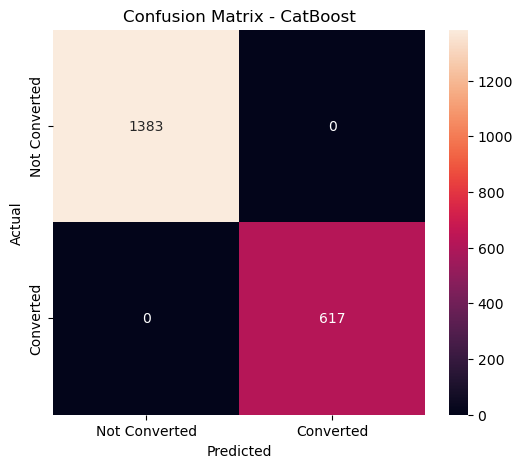

In [87]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


# Get validation probabilities
val_prob = final_model.predict_proba(
    X_val
)[:,1]


# Apply your best threshold
val_pred = (
    val_prob > best_cat_threshold
).astype(int)


# Confusion matrix
cm = confusion_matrix(
    y_val,
    val_pred
)


print(cm)


# Plot
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Not Converted", "Converted"],
    yticklabels=["Not Converted", "Converted"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - CatBoost")

plt.show()